# Loan Default Prediction Project



### Step 1: Initial Inspection

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('loan_approval_dataset.csv')
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


In [4]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')

### Step 2: Data Cleaning

In [5]:
import numpy as np

In [6]:
# Strip leading/trailing whitespace from column names
df.columns = df.columns.str.strip()

# Strip whitespace from string column values
for col in ['education', 'self_employed', 'loan_status']:
    df[col] = df[col].str.strip()

# Drop loan_id (just an identifier, no predictive value)
df = df.drop(columns=['loan_id'])

print(df.columns.tolist())
print('Shape:', df.shape)

['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']
Shape: (4269, 12)


In [7]:
# Check for missing values and duplicate rows
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [8]:
# Investigate negative values in residential_assets_value
neg_mask = df['residential_assets_value'] < 0
print('Negative count:', neg_mask.sum())
print('Unique negative values:', df.loc[neg_mask, 'residential_assets_value'].unique())

# All 28 are exactly -100,000 -> likely a placeholder for missing data, not real negative net worth
# Decision: treat as missing -> replace with NaN, impute with median inside the Pipeline
df.loc[neg_mask, 'residential_assets_value'] = np.nan
print('NaN count after replacement:', df['residential_assets_value'].isna().sum())

Negative count: 28
Unique negative values: [-100000]
NaN count after replacement: 28


In [9]:
# Check target variable distribution before encoding
print(df['loan_status'].value_counts())
print(df['loan_status'].value_counts(normalize=True).round(3))

# Encode target variable: Approved=1, Rejected=0
df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})
print('After encoding:', df['loan_status'].value_counts())

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64
loan_status
Approved    0.622
Rejected    0.378
Name: proportion, dtype: float64
After encoding: loan_status
1    2656
0    1613
Name: count, dtype: int64


In [10]:
# Save cleaned data with NaN preserved
# Important: do NOT impute here - imputation happens inside the Pipeline to prevent data leakage
df.to_csv('data_cleaned.csv', index=False)
print('Saved data_cleaned.csv')
print('Shape:', df.shape)
print('NaN in residential_assets_value:', df['residential_assets_value'].isna().sum())

Saved data_cleaned.csv
Shape: (4269, 12)
NaN in residential_assets_value: 28


### Step 3: Feature Engineering

In [11]:
df = pd.read_csv('data_cleaned.csv')

# total_assets: sum of 4 asset columns
# Note: residential_assets_value has 28 NaN -> total_assets will also have 28 NaN
# These NaN values will be handled by SimpleImputer(median) inside the Pipeline
df['total_assets'] = (df['residential_assets_value'] +
                      df['commercial_assets_value'] +
                      df['luxury_assets_value'] +
                      df['bank_asset_value'])

# Loan-to-income ratio (key financial indicator)
# Safe denominator: income_annum is always positive
df['loan_to_income_ratio'] = df['loan_amount'] / df['income_annum']

# Monthly payment as fraction of monthly income
df['payment_to_income'] = (df['loan_amount'] / df['loan_term']) / df['income_annum']

# Income per person in household (no_of_dependents + 1 avoids division by zero)
df['income_per_dependent'] = df['income_annum'] / (df['no_of_dependents'] + 1)

print('NaN in total_assets:', df['total_assets'].isna().sum())
print(df[['total_assets', 'loan_to_income_ratio', 'payment_to_income', 'income_per_dependent']].describe())

NaN in total_assets: 28
       total_assets  loan_to_income_ratio  payment_to_income  \
count  4.241000e+03           4269.000000        4269.000000   
mean   3.267043e+07              2.984807           0.435513   
std    1.948360e+07              0.595496           0.398879   
min    5.000000e+05              1.500000           0.075000   
25%    1.640000e+07              2.464286           0.187500   
50%    3.160000e+07              3.000000           0.275176   
75%    4.730000e+07              3.500000           0.505747   
max    9.070000e+07              4.000000           2.000000   

       income_per_dependent  
count          4.269000e+03  
mean           2.055050e+06  
std            2.003233e+06  
min            3.333333e+04  
25%            7.750000e+05  
50%            1.450000e+06  
75%            2.500000e+06  
max            9.900000e+06  


In [12]:
# Option A: drop original 4 asset columns to reduce multicollinearity
df = df.drop(columns=['residential_assets_value', 'commercial_assets_value',
                       'luxury_assets_value', 'bank_asset_value'])
print('Shape after dropping original asset columns:', df.shape)
print(df.columns.tolist())

Shape after dropping original asset columns: (4269, 12)
['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'loan_status', 'total_assets', 'loan_to_income_ratio', 'payment_to_income', 'income_per_dependent']


### Step 4: Baselines

In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

X_all = df.drop(columns=['loan_status'])
y_all = df['loan_status']

# Baseline 1: always predict the majority class (Approved)
dummy = DummyClassifier(strategy='most_frequent')
scores = cross_val_score(dummy, X_all[['cibil_score']], y_all, cv=5, scoring='f1')
print('Baseline 1 (DummyClassifier) F1:', scores.mean().round(4))

Baseline 1 (DummyClassifier) F1: 0.7671


In [14]:
from sklearn.metrics import f1_score, accuracy_score

# Baseline 2: business rule - CIBIL score >= 550 -> predict Approved
y_rule = (df['cibil_score'] >= 550).astype(int)
print('Baseline 2 (CIBIL Rule) Accuracy:', round(accuracy_score(y_all, y_rule), 4))
print('Baseline 2 (CIBIL Rule) F1:', round(f1_score(y_all, y_rule), 4))
print('-> Our final model must beat this F1 score to add value')

Baseline 2 (CIBIL Rule) Accuracy: 0.9536
Baseline 2 (CIBIL Rule) F1: 0.9615
-> Our final model must beat this F1 score to add value


### Step 5: Train / Test Split

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['loan_status'])
y = df['loan_status']

# Split BEFORE fitting any preprocessor to prevent data leakage
# stratify=y preserves class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Train y distribution:')
print(y_train.value_counts(normalize=True).round(3))
print('Test y distribution:')
print(y_test.value_counts(normalize=True).round(3))

Train: (3415, 11)  Test: (854, 11)
Train y distribution:
loan_status
1    0.622
0    0.378
Name: proportion, dtype: float64
Test y distribution:
loan_status
1    0.622
0    0.378
Name: proportion, dtype: float64


### Step 6: Preprocessing Pipeline

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_cols = ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
                'cibil_score', 'total_assets', 'loan_to_income_ratio',
                'payment_to_income', 'income_per_dependent']

categorical_cols = ['education', 'self_employed']

# Numeric pipeline: impute missing values with median, then scale
# Order matters: impute first, then scale (StandardScaler cannot handle NaN)
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: one-hot encode (drop='first' avoids dummy variable trap)
categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print('Preprocessor defined.')
print('Numeric cols:', numeric_cols)
print('Categorical cols:', categorical_cols)
print('Note: imputer + scaler are fit only on X_train during CV -> no data leakage')

Preprocessor defined.
Numeric cols: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'total_assets', 'loan_to_income_ratio', 'payment_to_income', 'income_per_dependent']
Categorical cols: ['education', 'self_employed']
Note: imputer + scaler are fit only on X_train during CV -> no data leakage


### Step 7: Initial Model Comparison

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix,
                              classification_report, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

print('Initial Model Comparison (5-fold CV, default params)')
print('=' * 55)
print(f"{'Model':<25} {'F1 Mean':>10} {'F1 Std':>10}")
print('-' * 55)
for name, model in models.items():
    pipe = Pipeline([('preproc', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1')
    print(f'{name:<25} {scores.mean():>10.4f} {scores.std():>10.4f}')
print('-' * 55)
print(f"{'Baseline 2 (CIBIL Rule)':<25} {'0.9615':>10}")

Initial Model Comparison (5-fold CV, default params)
Model                        F1 Mean     F1 Std
-------------------------------------------------------
Logistic Regression           0.9478     0.0060
KNN                           0.9439     0.0096
Random Forest                 0.9970     0.0018
Gradient Boosting             0.9962     0.0017
-------------------------------------------------------
Baseline 2 (CIBIL Rule)       0.9615


### Step 8: Hyperparameter Tuning (GridSearchCV)

In [19]:
param_grid_lr = {'model__C': [0.01, 0.1, 1, 10, 100]}
pipe_lr = Pipeline([('preproc', preprocessor),
                    ('model', LogisticRegression(max_iter=1000, random_state=42))])
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)
print('LR Best params:', grid_lr.best_params_)
print('LR Best CV F1:', round(grid_lr.best_score_, 4))

LR Best params: {'model__C': 10}
LR Best CV F1: 0.9483


In [20]:
param_grid_knn = {
    'model__n_neighbors': [3, 5, 7, 11, 15, 21],
    'model__weights': ['uniform', 'distance']
}
pipe_knn = Pipeline([('preproc', preprocessor), ('model', KNeighborsClassifier())])
grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=5, scoring='f1', n_jobs=-1)
grid_knn.fit(X_train, y_train)
print('KNN Best params:', grid_knn.best_params_)
print('KNN Best CV F1:', round(grid_knn.best_score_, 4))

KNN Best params: {'model__n_neighbors': 21, 'model__weights': 'distance'}
KNN Best CV F1: 0.9571


In [21]:
param_grid_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}
pipe_rf = Pipeline([('preproc', preprocessor),
                    ('model', RandomForestClassifier(random_state=42))])
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print('RF Best params:', grid_rf.best_params_)
print('RF Best CV F1:', round(grid_rf.best_score_, 4))

RF Best params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
RF Best CV F1: 0.997


In [22]:
param_grid_gb = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7]
}
pipe_gb = Pipeline([('preproc', preprocessor),
                    ('model', GradientBoostingClassifier(random_state=42))])
grid_gb = GridSearchCV(pipe_gb, param_grid_gb, cv=5, scoring='f1', n_jobs=-1)
grid_gb.fit(X_train, y_train)
print('GB Best params:', grid_gb.best_params_)
print('GB Best CV F1:', round(grid_gb.best_score_, 4))

GB Best params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100}
GB Best CV F1: 0.997


### Step 9: Select Final Model

In [23]:
results = {
    'Logistic Regression': grid_lr.best_score_,
    'KNN': grid_knn.best_score_,
    'Random Forest': grid_rf.best_score_,
    'Gradient Boosting': grid_gb.best_score_,
}

print('Tuned Model Comparison (Best CV F1)')
print('=' * 50)
for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    flag = 'BEATS BASELINE' if score > 0.9615 else 'below baseline'
    print(f'{name:<25} {score:.4f}  {flag}')
print('=' * 50)
print(f"{'Baseline 2 (CIBIL Rule)':<25} 0.9615")

grid_map = {'Logistic Regression': grid_lr, 'KNN': grid_knn,
            'Random Forest': grid_rf, 'Gradient Boosting': grid_gb}
best_name = max(results, key=results.get)
best_model = grid_map[best_name]
print(f'\nFinal model selected: {best_name}')

Tuned Model Comparison (Best CV F1)
Random Forest             0.9970  BEATS BASELINE
Gradient Boosting         0.9970  BEATS BASELINE
KNN                       0.9571  below baseline
Logistic Regression       0.9483  below baseline
Baseline 2 (CIBIL Rule)   0.9615

Final model selected: Random Forest


### Step 10: Threshold Optimization

In [24]:
probs_cv = cross_val_predict(
    best_model.best_estimator_, X_train, y_train, cv=5, method='predict_proba'
)[:, 1]

best_t, best_f1_cv = 0.5, 0.0
for t in np.arange(0.1, 0.95, 0.05):
    preds = (probs_cv >= t).astype(int)
    f1 = f1_score(y_train, preds)
    if f1 > best_f1_cv:
        best_f1_cv, best_t = f1, t

print(f'Best threshold: {best_t:.2f}  ->  CV F1 = {best_f1_cv:.4f}')
best_threshold = best_t

Best threshold: 0.60  ->  CV F1 = 0.9972


### Step 11: Final Test Set Evaluation

In [25]:
test_probs = best_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

print('=' * 50)
print('FINAL TEST SET RESULTS')
print('=' * 50)
print(f'Accuracy:  {accuracy_score(y_test, test_preds):.4f}')
print(f'Precision: {precision_score(y_test, test_preds):.4f}')
print(f'Recall:    {recall_score(y_test, test_preds):.4f}')
print(f'F1:        {f1_score(y_test, test_preds):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, test_probs):.4f}')
print()
print('Confusion Matrix:')
print(confusion_matrix(y_test, test_preds))
print()
print(classification_report(y_test, test_preds))

improvement = f1_score(y_test, test_preds) - 0.9615
print(f'Baseline 1 (naive)          F1: ~0.7700')
print(f'Baseline 2 (CIBIL rule)     F1:  0.9615')
print(f'Final ML model ({best_name}) F1:  {f1_score(y_test, test_preds):.4f}')
print(f'Improvement over Baseline 2: {improvement:+.4f}')

FINAL TEST SET RESULTS
Accuracy:  0.9953
Precision: 0.9925
Recall:    1.0000
F1:        0.9962
ROC-AUC:   0.9996

Confusion Matrix:
[[319   4]
 [  0 531]]

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       323
           1       0.99      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      0.99      1.00       854
weighted avg       1.00      1.00      1.00       854

Baseline 1 (naive)          F1: ~0.7700
Baseline 2 (CIBIL rule)     F1:  0.9615
Final ML model (Random Forest) F1:  0.9962
Improvement over Baseline 2: +0.0347


### Step 12: Visualizations

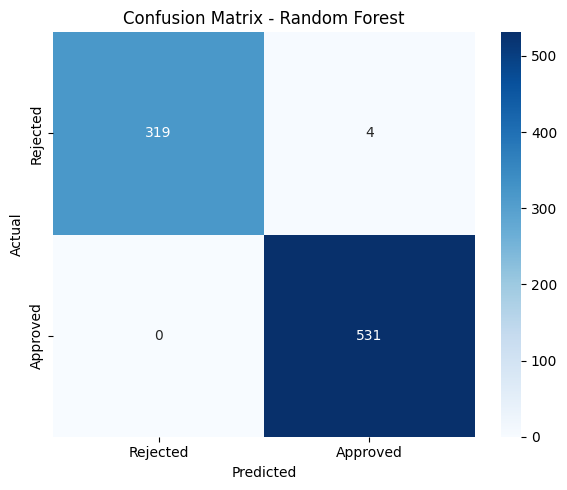

Saved confusion_matrix.png


In [26]:
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved confusion_matrix.png')

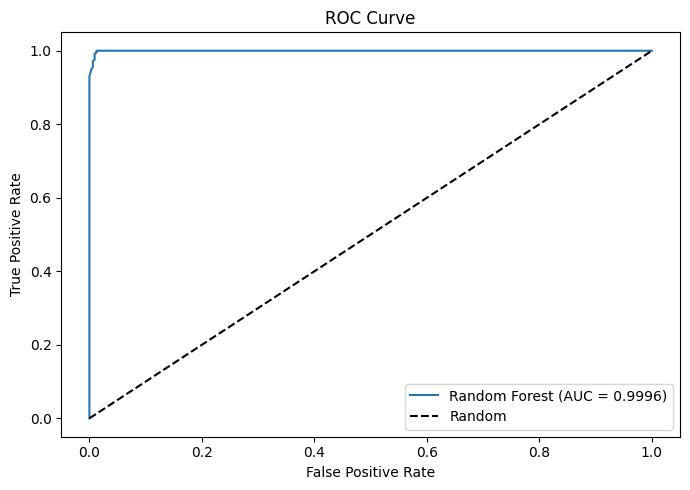

Saved roc_curve.png


In [27]:
fpr, tpr, _ = roc_curve(y_test, test_probs)
auc = roc_auc_score(y_test, test_probs)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'{best_name} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print('Saved roc_curve.png')

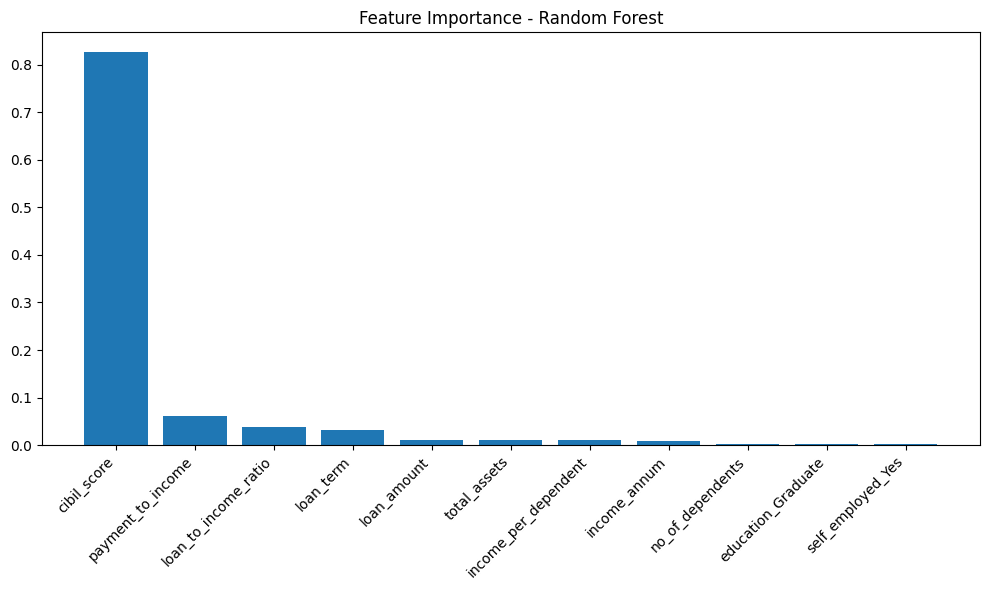

Saved feature_importance.png


In [28]:
final_estimator = best_model.best_estimator_.named_steps['model']
feature_names = numeric_cols + ['education_Graduate', 'self_employed_Yes']

if hasattr(final_estimator, 'feature_importances_'):
    importances = final_estimator.feature_importances_
    indices = importances.argsort()[::-1]
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)),
               [feature_names[i] for i in indices], rotation=45, ha='right')
    plt.title(f'Feature Importance - {best_name}')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()
    print('Saved feature_importance.png')
else:
    print(f'{best_name} does not have feature_importances_. Skipping.')

### Step 13: Save Final Model

In [29]:
joblib.dump(best_model, 'final_model.pkl')
print(f'Saved final_model.pkl  ({best_name})')
print('To reload: model = joblib.load("final_model.pkl")')

Saved final_model.pkl  (Random Forest)
To reload: model = joblib.load("final_model.pkl")


In [30]:
print("=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)
print(f"Dataset: 4,269 loans, 11 features (after engineering)")
print(f"Problem: Binary classification (Approved=1 / Rejected=0)")
print()
print("BASELINES")
print(f"  Naive (always Approved)  F1: 0.7671")
print(f"  CIBIL Rule (>= 550)      F1: 0.9615  <- bar to beat")
print()
print(f"BEST ML MODEL: {best_name}")
print(f"  Best CV F1 (tuned):      {best_model.best_score_:.4f}")
print(f"  Test F1:                 {f1_score(y_test, test_preds):.4f}")
print(f"  Test ROC-AUC:            {roc_auc_score(y_test, test_probs):.4f}")
print(f"  Optimal threshold:       {best_threshold:.2f}")
print()
improvement = f1_score(y_test, test_preds) - 0.9615
print(f"Improvement over CIBIL rule: {improvement:+.4f}")
print("=" * 60)

PROJECT SUMMARY
Dataset: 4,269 loans, 11 features (after engineering)
Problem: Binary classification (Approved=1 / Rejected=0)

BASELINES
  Naive (always Approved)  F1: 0.7671
  CIBIL Rule (>= 550)      F1: 0.9615  <- bar to beat

BEST ML MODEL: Random Forest
  Best CV F1 (tuned):      0.9970
  Test F1:                 0.9962
  Test ROC-AUC:            0.9996
  Optimal threshold:       0.60

Improvement over CIBIL rule: +0.0347
